In [11]:
import pybamm
import numpy as np

def U_nmc(x):
    return (13.49050
            - 10.96038 * x
            + 8.203617 * x ** 1.358699
            - 3.10758e-6 * pybamm.exp(127.1216 * x - 114.2593)
            - 7.033556 * x ** (-3.362749e-2))
    
crate = 1

common_params = {
    # Geometry
    "L_sep": 75e-6 / 2,
    "L_anode": 75e-6,

    # Butler-Folmer
    "Fk": 4.824e-6,
    "C_max": 50400,
    "j0_li": 10,
    "U": U_nmc,

    # Electrolyte
    "D_e": 1e-10,
    "kappa_e": 1.0,
    "t_plus": 0.4,
    "eps_sep": 0.4,
    "tau_sep": 2.28,
    "eps_s": 0.483,
    "tau_anode": 0.517/0.160,

    # Solid
    "kappa_s_eq": 60.0,

    # General
    "T": 298.15,
    
    # Current
    "I": lambda t: pybamm.constants.F * 75e-6 * 0.483 * 50400 / 3600 * crate,

    # Initial
    "C_e_0": 1000,
    "C_s_0": 25000,
    
    # Cutoff
    "u_min" : 3,
    "u_max" : 4.2
}

param_DC1 = common_params.copy()
param_DC1.update({
    "<s>": -190.7,
    "a": 736526,
})
param_DC1 = pybamm.ParameterValues(param_DC1)

param_DFN = common_params.copy()
param_DFN.update({
    "R_p": 0.971e-6,
    "D_s": 4e-14,
})
param_DFN = pybamm.ParameterValues(param_DFN)

from DFN import DFN
from DC1 import DC1

t_eval = np.linspace(0, 2500, 4001)

dfn = DFN()
dc1 = DC1()
solution_dfn = dfn.run(param_DFN, 60, 60, t_eval)
solution_dc1 = dc1.run(param_DC1, 60, t_eval)

dfn_stop = solution_dfn.t[-1]
dc1_stop = solution_dc1.t[-1]

param_DFN["I"] = lambda t: pybamm.constants.F * 75e-6 * 0.483 * 50400 / 3600 * crate * (t < dfn_stop-1)
param_DC1["I"] = lambda t: pybamm.constants.F * 75e-6 * 0.483 * 50400 / 3600 * crate * (t < dc1_stop-1)

solution_dfn = dfn.run(param_DFN, 60, 60, t_eval)
solution_dc1 = dc1.run(param_DC1, 60, t_eval)

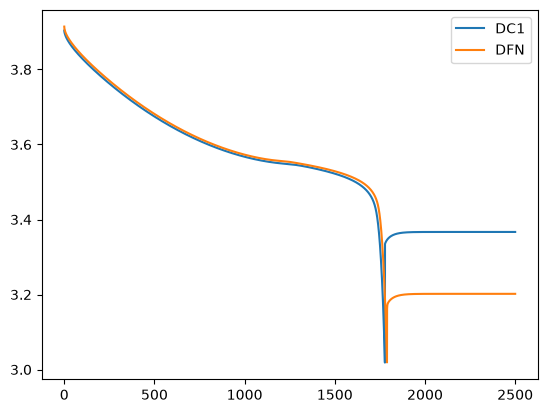

In [12]:
import matplotlib.pyplot as plt

plt.plot(solution_dc1.t, solution_dc1["voltage"].data, label="DC1")
plt.plot(solution_dfn.t, solution_dfn["voltage"].data, label="DFN")
plt.legend()